# Week 3 Activity: Synthesis Functions

Complete this activity as part of your participation grade. Pending length of the lecture, you will have time in class to work. Everything you need to complete this activity can be found in this week's (or a previous week's) lecture code. For this activity, you may want to consult your Audio Tech I notes (or the Computer Music Tutorial)

In [1]:
import numpy as np
from IPython.display import Audio
import matplotlib.pyplot as plt
from scipy.io.wavfile import read
from scipy import signal
fs = 44100
def genSine(f, a=1, fs=44100, t=1, phi=0):
    # checkInput(f, a, fs, t, phi)
    return a*np.sin(2*np.pi*f*np.arange(0,t,1/fs) + phi)

## 1. Create an envelope function

Write a function called adsr() that will modify a passed sound according to an ADSR envelope that is user-defined. 
Your function should include the following arguments at a minimum:

1) a: Time to reach maximum amplitude (can be zero to length of input). (float)

2) s: The level (amplitude) of the sustain portion. (float)

3) d: Time to descend from max to sustain level (N.B. time can be zero, and sustain can be False.) (float)

4) r: Time to descend to zero (N.B. should be a minimum of 20ms). (float)

5) x: array of samples of length n that will be modulated by the envelope. (np.array)

Your function should return the input sound modified by the envelope

**Notes**

Optimizing your function:  The following are things to consider, but not necessary as a "first step":  

* Your function ideally should allow for all scenarios including passing sound arrays of various lengths, and, it should allow for a sharp attack followed by an immediate decay with zero sustain (like a plucked or percussive sound) regardless of the total length of the sound passed. I.e., If there is no sustain value, then the Decay (#3) and Sustain (#2) are moot, so your function should just ascend to peak value over some time, x, and then descend to zero over time x.

* Be sure to include default values to all your arguments (except #5)

* You will need to define additional defaults within the function such as the sample rate. (You may want to make this an argument variable with a default value).


Heads up: This will likely be the most tedious question of this activity as it is a lot of array manipulation and edge case finding. 

Note: depending on your implementation, the following functions may come in handy:

`np.max` returns the maximum value in an array  
`np.min` returns the minimum value in an array  
`np.size` returns the total length of an array   
`np.where` returns index value(s) matching boolean conditions  
`np.zeros(n)` returns an array of zeros of length n  
`np.ones(n)` returns an array of ones of length n  
`np.full(n, val)` returns an array of values (val) of length n  

In [4]:
# This is going to be fun!



# Support arr of any length
# Support case where 0 sustain time (adr)
# Include defaults

# I don't want to include s-time. Let's  figure that out first.
# I want my adsr sustain to work by using a gate signal (much
#like) VCV rack and MaxMSP. I can create a helper method to 
# create gates with zeroes and ones functions for specified times.
# That way ADSR feels more at home!

# We are limited by the fact that this is not real-time coding.
# Our input signals are not continuously flowing. They have lengths.


# How about this
# class adsr. Creates an envelope generator object.
# class useful b/c use same parameters for multiple envelopes
# It has a method gen(gate) which converts a gate into the signal
# The gate being an on and off signal.
# The adsr is built with retirgger so it retriggers according to the gate.
# supporting different arrs: create the envelope, then pad one of the arrays
# so that they are of equal length. may need to retrigger to avoid popping sound

# retrigger: I'd like it to be built in a real-time sort of way
# Upon new gate, ramp down to 0 in the retrigger time and begin
# creating that envelope. retrig time will be part of release of last gate

# No sustain case - just use a short gate. it won't get to sustain,
# it will start release during low gate.
# x - input signal (np.array)

# the way it works in rack is if gate is too short, it skips to equivalent
# part of the release phase so there is no clipping.

# there are edge cases for when retrigger ends up being longer than some parts


def toSamples(*msTimes, fs=fs):
    """
    Convert ms times to samples. (np array)
    Works for individual args or unpacked np array
    """
    return (fs * np.array(msTimes) / 1000).astype(int)


def genGates(high, *lowHigh, fs=fs):
    """
    high - time of HIGH phase of gate (ms)
    lowHigh - subsequent gates specified by time of LOW phase
    followed by time of HIGH phase of next gate, etc.
    Out: np.array of gates in samples

    # pad beginning on both ends by one sample
    # factor end pad into time of low sample
    """
    sampleLengths = toSamples(*np.insert(lowHigh, 0, high), fs=fs)
    gates = np.concatenate([(np.ones, np.zeros)[i%2](length) 
                            for i, length in enumerate(sampleLengths)])
    return np.pad(gates, (1, 1))


class ADSR:
    """
    Envelope-generator object. Converts a gate into an envelope signal
    """
    def __init__(self, a=100, d=100, s=0.5, r=100, retr=10, fs=fs):
        """
        a - attack time (ms)
        d - decay time (ms)
        s - sustain level 0 <= s <= 1
        r - release time (ms)
        retr - retrigger time (ms)
        fs - sample rate (Hz)
        """
        self.a = a
        self.d = d
        self.s = s
        self.r = r
        self.fs = fs

    def gen(self, inputSig, gate):
        """
        It's not real time, but I was wanted to create my function as
        if it was real time.
        """
        aSamps,dSamps,rSamps = toSamples(self.a, self.d, self.r, fs=self.fs)
        sLevel = self.s
        # create envelope from adsr and gate signal
        # It's not real time even though I kind of wanted it to be
        # for data in gate.
        # 

        a = np.linspace(0, 1, aSamps, endpoint=False)
        d = np.linspace(1, sLevel, dSamps, endpoint=False)
        s = np.full(sSamps, sLevel)
        r = np.linspace(sLevel, 0, rSamps, endpoint=False)
        env = np.concatenate((a,d,s,r))

        # if gate = 1, att, dec, sus
        # if gate = 0 release

        sTime = None

        # if env < input sig, pad env by remaining distance
        # else: retrigger to 0 and then pad by remaining distance
        return inputSig * env
    def iteratorTest(self, gate):
        aSamps,dSamps,rSamps = toSamples(self.a, self.d, self.r, fs=self.fs)

        sLevel = self.s
        lastBit = 0

        def switch(bit):
            if condition(bit):
                return True
            condition = lambda bit: not condition(bit)
            return False
            
            # if bit != lastBit, return False and switch condition.
            if not bit:
        for bit in gate:
             # need a switcher.
             if switch(bit)
                yield next(phaseADS)
            else
                rTime = None
                yield next(phaseR)
            
   
   
   
        #      for val in np.linspace(0, 1, aSamps, endpoint=False): # A
        #         if not bit:
        #             break
        #         yield val
        # pass
        # input bit of gate
        # if 0, start with A phase, yield


gates = genGates(10, 100, 500, 40, 300)
plt.plot(1000*np.arange(gates.size)/fs, gates)

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 129)

In [2]:
a = np.arange(5)
def foo(*args):
    print(args)
foo(*a)

(0, 1, 2, 3, 4)


## 2. Create an amplitude modulation function

1. Write a function called amp_mod() for amplitude modulation. Your function should have the following arguments at minimum.

* carrier input signal (np.array)
* sampling rate (float)
* frequency of modulator (float)
* wave shape of the modulator (string: 'sine', 'square', 'tri', 'saw')
* boolean for polarity - should it be bipolar (True or False)

You need sampling rate to determine the proper relationship to length of the array and frequency.

Note: 
* modulator wave_shape --> should be sinusoid, square, sawtooth, or triangle (you may use `scipy.signal` library to make it easier - see: https://docs.scipy.org/doc/scipy/reference/signal.html and scroll to "Waveforms")  
* time --> the time or length of the carrier signal (modulator should exactly match)


In [6]:
def amp_mod(carrier, modFreq, shape="sine", unipolar=True, fs=fs):
    wave = {
        "sine" : np.sin,
        "square": signal.square,
        "tri": lambda t: signal.sawtooth(t, width=0.5),
        "saw": signal.sawtooth
    }[shape]

    t = np.arange(0, carrier.size/fs, 1/fs)
    modulator = unipolar + wave(2*np.pi * modFreq * t)
    return carrier * modulator / 2

2. Apply your function to the following scenarios.

a) Apply ring modulation with a square wave with a mod frequency of 50 Hz to a loaded audio file

In [4]:
fs_gtr, gtr = read("../audio/AcousticGuitar.wav")
# truncating to reduce loading time
gtr = gtr[:int(gtr.size/4)]
print(fs_gtr, gtr)
Audio(gtr, rate=fs_gtr)

44100 [  0  21  42 ... 579 545 517]


In [25]:
mod_gtr = amp_mod(gtr, 50, "square", False, fs_gtr)
# terrible. Is it clipping? Or is the square wave causing discontinuities
# by abruptly jumping up and down
Audio(mod_gtr, rate=fs_gtr)

b) Apply amplitude modulation with a sine wave to a 200 Hz sine wave with an arbitrary modulator frequency. Plot the magnitude spectrum.

modulator freq: 610
    expected spectrum of f = [200, 410, 810]


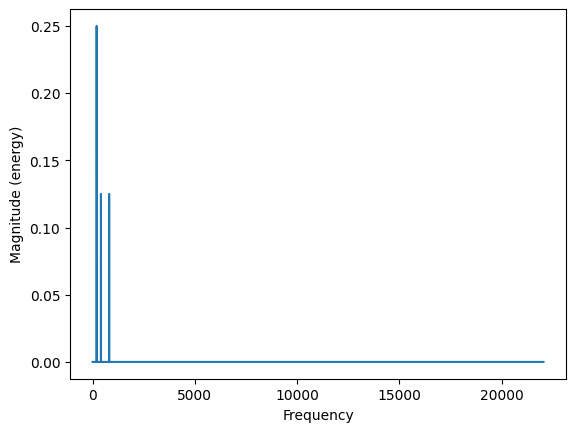

In [61]:
rand = int(50 + np.random.random()*1000)
mod = amp_mod(genSine(200), rand, "sine")
plt.magnitude_spectrum(mod, Fs=fs,)
print(f"""modulator freq: {rand}
    expected spectrum of f = {sorted([abs(200-rand),200, 200+rand])}""")

c) Apply ring modulation with a sine wave to a 200 Hz sine wave with a modulator frequency such that the output is inharmonic. Plot the magnitude spectrum.

modulator freq: 628.3185307179587
    expected spectrum of f = [428.31853071795865, 828.3185307179587]


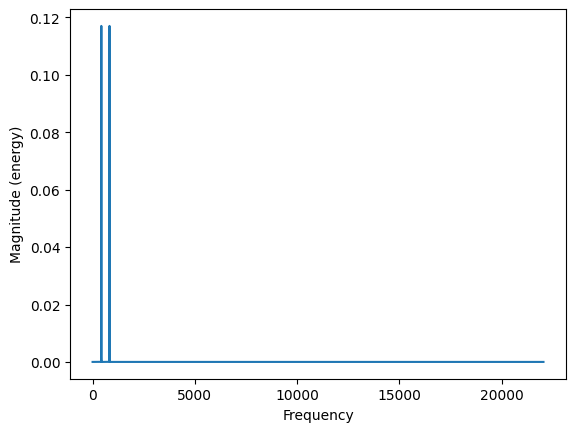

In [58]:
modFreq = 200*np.pi
mod = amp_mod(genSine(200), modFreq, "sine", unipolar=False)
plt.magnitude_spectrum(mod, Fs=fs,)
print(f"""modulator freq: {modFreq}
    expected spectrum of f = {[abs(200-modFreq), 200+modFreq]}""")

d) Apply ring modulation with a sine wave to a 200 Hz sine wave with a modulator frequency such that the output only seems to have 1 frequency component. Plot the magnitude spectrum.

modulator freq: 200
    expected spectrum of f = [0, 400]


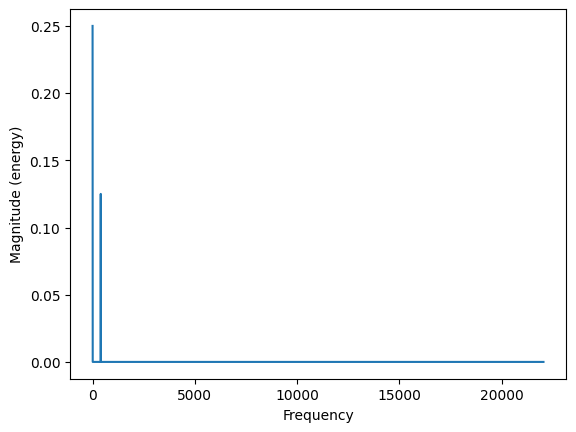

In [63]:
modFreq = 200
# modFreq = 0 works too, but then it would actually have 1 frequency compoent
mod = amp_mod(genSine(200), modFreq, "sine", unipolar=False)
plt.magnitude_spectrum(mod, Fs=fs,)
print(f"""modulator freq: {modFreq}
    expected spectrum of f = {[abs(200-modFreq), 200+modFreq]}""")

## 3. Create an FM synthesis function 

1. Create a function called fmSynth() for FM synthesis (or more aptly PM synthesis). Your function should include the following arguments.

* Depth of modulation *or* modulation index (float) 
* Carrier frequency (float)
* Modulator frequency (float)
* time in seconds (float)

Your function should return a np.array with the synthesized sound

In [64]:
# I+1 Harmonics at C +- nM
# Fundamental is GCD(C, M)
def fmSynth(I, C, M, T):
    # (pm)
    t = np.arange(0, T, 1/fs)
    modulator = np.sin(2*np.pi*M*t)
    return np.sin(2*np.pi*C*t + I*modulator)

2) Using your function, try to create the following types of sounds. Try to understand the relation between the modulator and carrier in contributing to harmonic versus inharmonic sounds.

a) Inharmonic   

In [106]:
# C/M irrational, lots of sidebands
Audio(fmSynth(16, 400, 400/np.pi, 2), rate=fs)

 b) harmonic where the carrier is the fundamental  


In [88]:
# I+1 Harmonics at C +- nM
# Fundamental is GCD(C, M)
# Given integer ratio C : M, C determines starting harmonic, 
# M determines harmonic spread. (by formula above)
# So I'm varying harmonic spread here.
# 
spread = int(1 + np.random.random()*5)
print(spread)
Audio(fmSynth(3, 400, 400*spread, 2), rate=fs)

1


c) harmonic where the carrier is not the fundamental.  

In [117]:
# fundamental is GCD(C, M)
# GCD(C, M) != C is always true if M < C b/c GCD(C, M) <= min(C,M) = M
# Therefore GCD(C,M) <= M < C -> GCD(C,M) != C
# if M > C, and GCD(C, M) != C, then M cannot be integer multiple of C.
# Still the output can be harmonic if there is a smaller GCD below C and M.
# General case is M = (n1/n2)C, where n1/n2 is a simplified fraction
    # (GCD(n1,n2) = 1), and n2 != 1
# Then GCD(C, M) = GCD((C, n1/n2)C) = (C/n2)GCD(n2, n1) = C/n2
# f0 = C/n2 -> f0 * n1 = M, f0 * n2 = C, C +- nM = f0*n2 +- f0*n*n1
    # = f0(n2 +- n*n1)
# So all sidebands would be harmonics of f0, producing harmonic output
# Given the conditions, M will never be a multiple of C, so C will never be
# the fundamental.

# 2 random coprime integers
n2 = int(2 + np.random.random()*8)
n1 = int(1 + np.random.random()*8)
while n1 % n2 == 0:
    n1 = int(1 + np.random.random()*8)


print(f"M = ({n1}/{n2})C, Fundamental: {400/n2}"
      + "\n That also means fundamental is only dependent on n2")
Audio(fmSynth(3, 400, 400*n1/n2, 2), rate=fs)

M = (7/8)C, Fundamental: 50.0
 That also means fundamental is only dependent on n2
